In [89]:
#_____Bibliotheken importieren_____
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [90]:
#_____Datensatz laden und Polteinstellungen_____
df = pd.read_csv('werkzeugbruch_training.csv')

  Datensatz: werkzeugbruch_training.csv

Shape      : 5,000 Zeilen × 4 Spalten
Bruchrate  : 5.24%  (262 Brüche / 5000 Samples)

── Erste 5 Zeilen ───────────────────────────────────
   depth_of_cut  feed_rate  tool_wear_min  tool_breakage
0          1.22      0.191           66.7              0
1          3.46      0.254          102.8              0
2          3.23      0.183           22.8              0
3          2.89      0.280           73.4              0
4          1.62      0.314           31.5              0

── Statistische Kennzahlen (Features) ───────────────
       depth_of_cut  feed_rate  tool_wear_min
count      5000.000   5000.000       5000.000
mean          2.242      0.278         58.950
std           1.181      0.156         34.687
min           0.500      0.050          0.000
25%           1.270      0.143         28.400
50%           2.040      0.251         58.900
75%           3.072      0.403         88.600
max           4.990      0.600        120.000

── Kla

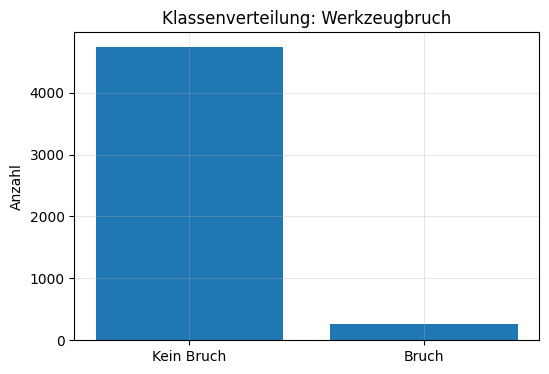

In [91]:
#_____Erste Datenanalyse_____
df = pd.read_csv('werkzeugbruch_training.csv')

print("=" * 55)
print("  Datensatz: werkzeugbruch_training.csv")
print("=" * 55)
print(f"\nShape      : {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"Bruchrate  : {df['tool_breakage'].mean():.2%}  "
      f"({df['tool_breakage'].sum()} Brüche / {len(df)} Samples)\n")

print("── Erste 5 Zeilen ───────────────────────────────────")
print(df.head().to_string(index=True))

print("\n── Statistische Kennzahlen (Features) ───────────────")
print(df[['depth_of_cut', 'feed_rate', 'tool_wear_min']].describe().round(3).to_string())

print("\n── Klassenverteilung ─────────────────────────────────")
vc = df['tool_breakage'].value_counts()
print(f"  Klasse 0 (kein Bruch): {vc[0]:5,}  ({vc[0]/len(df):.1%})")
print(f"  Klasse 1 (Bruch)     : {vc[1]:5,}  ({vc[1]/len(df):.1%})")

plt.figure(figsize=(6,4))
plt.bar(['Kein Bruch', 'Bruch'], [vc[0], vc[1]])
plt.ylabel('Anzahl')
plt.title('Klassenverteilung: Werkzeugbruch')
plt.show()

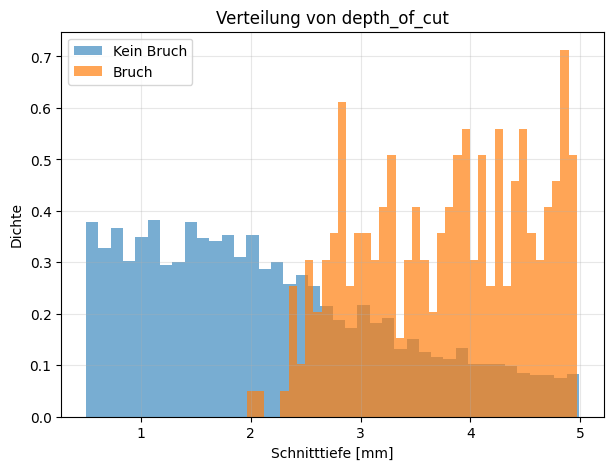

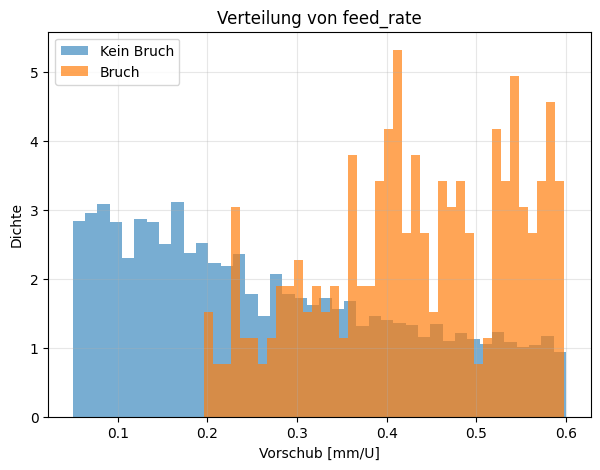

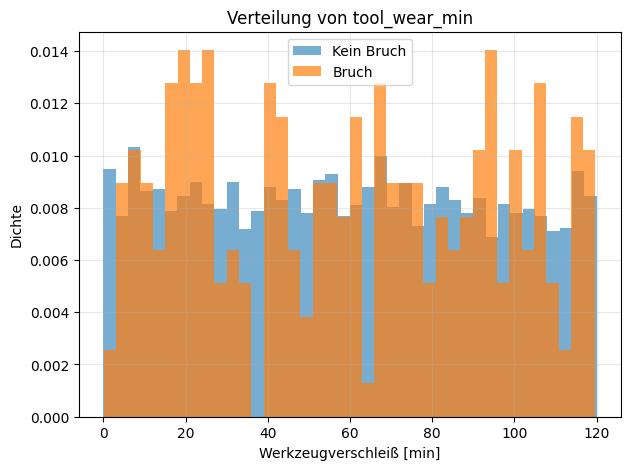

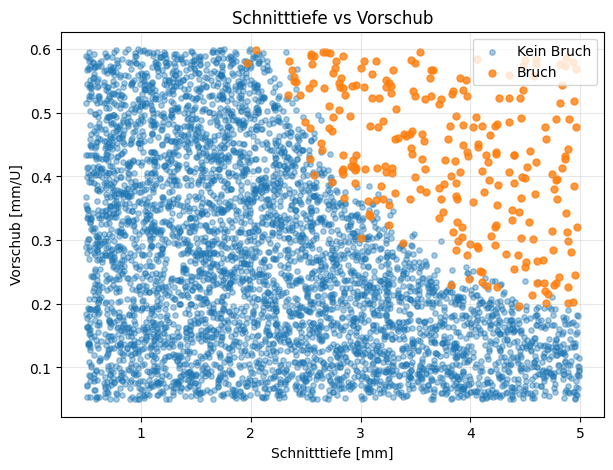

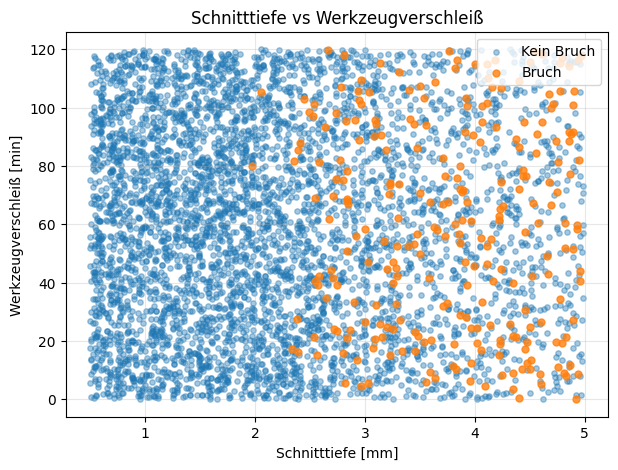

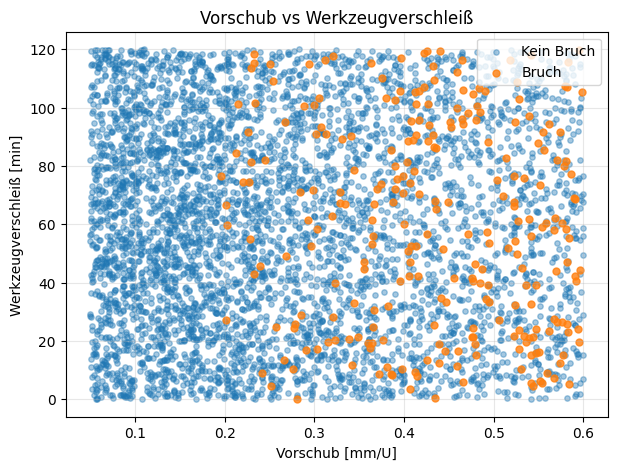

In [92]:
# ── Feature-Verteilungen nach Klasse ──────────────────────────────────────────
features = ['depth_of_cut', 'feed_rate', 'tool_wear_min']

# feature_labels ist ein Dictionary, das die technischen Namen der Features (z.B. 'depth_of_cut') den lesbaren Bezeichnungen (z.B. 'Schnitttiefe [mm]') zuordnet, die in den Plots verwendet werden.
feature_labels = {
'depth_of_cut': 'Schnitttiefe [mm]',
'feed_rate': 'Vorschub [mm/U]',
'tool_wear_min': 'Werkzeugverschleiß [min]'
}

# Die Schleife läudt über jedes Feature in der Liste 'features' und erstellt für jedes Feature ein Histogramm. es Zeigt die Verteilung des Features für die beiden Klassen (kein Bruch vs. Bruch). Die Daten werden dabei in zwei Gruppen aufgeteilt: df_kein_bruch enthält die Zeilen ohne Bruch (tool_breakage == 0) und df_bruch enthält die Zeilen mit Bruch (tool_breakage == 1). 
for feature in features:
    
    # 7,5 setht für die Größe der Abbildung in Zoll (Breite x Höhe)
    plt.figure(figsize=(7,5))

    df_kein_bruch = df[df['tool_breakage'] == 0]
    df_bruch = df[df['tool_breakage'] == 1]

    plt.hist(df_kein_bruch[feature], bins=40, alpha=0.6, label='Kein Bruch', density=True)
    plt.hist(df_bruch[feature], bins=40, alpha=0.7, label='Bruch', density=True)

    plt.xlabel(feature_labels[feature])
    plt.ylabel('Dichte')
    plt.title(f'Verteilung von {feature}')
    plt.legend()
    plt.show()


# ── plots der Feature-Kombinationen ────────────────────────────────────
plt.figure(figsize=(7,5))
# df[df['tool_breakage']==0] filtert die Zeilen, bei denen kein Bruch vorliegt, und df[df['tool_breakage']==1] filtert die Zeilen mit Bruch.
plt.scatter(df[df['tool_breakage']==0]['depth_of_cut'], df[df['tool_breakage']==0]['feed_rate'], s=15, alpha=0.4, label='Kein Bruch')
plt.scatter(df[df['tool_breakage']==1]['depth_of_cut'], df[df['tool_breakage']==1]['feed_rate'], s=25, alpha=0.8, label='Bruch')
plt.xlabel('Schnitttiefe [mm]')
plt.ylabel('Vorschub [mm/U]')
plt.title('Schnitttiefe vs Vorschub')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df[df['tool_breakage']==0]['depth_of_cut'], df[df['tool_breakage']==0]['tool_wear_min'], s=15, alpha=0.4, label='Kein Bruch')
plt.scatter(df[df['tool_breakage']==1]['depth_of_cut'], df[df['tool_breakage']==1]['tool_wear_min'], s=25, alpha=0.8, label='Bruch')
plt.xlabel('Schnitttiefe [mm]')
plt.ylabel('Werkzeugverschleiß [min]')
plt.title('Schnitttiefe vs Werkzeugverschleiß')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df[df['tool_breakage']==0]['feed_rate'], df[df['tool_breakage']==0]['tool_wear_min'], s=15, alpha=0.4, label='Kein Bruch')
plt.scatter(df[df['tool_breakage']==1]['feed_rate'], df[df['tool_breakage']==1]['tool_wear_min'], s=25, alpha=0.8, label='Bruch')
plt.xlabel('Vorschub [mm/U]')
plt.ylabel('Werkzeugverschleiß [min]')
plt.title('Vorschub vs Werkzeugverschleiß')
plt.legend()
plt.show()

In [93]:
#_____ Interpretation der Plots _____
print("depth_of_cut trennt Klassen sehr gut (bei etwa2.5mm), feed_rate trennt auch gut (bei etwa 0.15mm/U), tool_wear_min trennt schlecht, da beide Klassen ähnliche Werte haben(liegen fasst überall übereinander).")
print("deutliche Trennung der Klassen bei Feature-Kombination \"Schnitttiefe vs Vorschub\". Bei den anderen Kombinationen gibt es mehr Überlappung zwischen den Klassen.")


depth_of_cut trennt Klassen sehr gut (bei etwa2.5mm), feed_rate trennt auch gut (bei etwa 0.15mm/U), tool_wear_min trennt schlecht, da beide Klassen ähnliche Werte haben(liegen fasst überall übereinander).
deutliche Trennung der Klassen bei Feature-Kombination "Schnitttiefe vs Vorschub". Bei den anderen Kombinationen gibt es mehr Überlappung zwischen den Klassen.


In [94]:
# ── Aufgabe 2: Feature Engineering ────────────────────────────────────────────

# Kopie vom ursprünglichen DataFrame erstellen
df_features = df.copy()

# Neue Überschrift ausgeben
print("=" * 60)

# Titel ausgeben
print("Aufgabe 2: Feature Engineering")

# Neue Trennlinie ausgeben
print("=" * 60)


# Feature 1: Schnitttiefe mal Vorschub berechnen
df_features["cut_feed"] = df_features["depth_of_cut"] * df_features["feed_rate"]

# Feature 2: Schnitttiefe mal Werkzeugverschleiß berechnen
df_features["cut_wear"] = df_features["depth_of_cut"] * df_features["tool_wear_min"]

# Feature 3: Vorschub mal Werkzeugverschleiß berechnen
df_features["feed_wear"] = df_features["feed_rate"] * df_features["tool_wear_min"]

# Feature 4: Alle drei Prozessgrößen miteinander multiplizieren
df_features["total_load"] = df_features["depth_of_cut"] * df_features["feed_rate"] * df_features["tool_wear_min"]

# Feature 5: Schnitttiefe quadrieren
df_features["depth_squared"] = df_features["depth_of_cut"] ** 2

# Feature 6: Vorschub quadrieren
df_features["feed_squared"] = df_features["feed_rate"] ** 2

# Feature 7: Werkzeugverschleiß quadrieren
df_features["cut_feed_squared"] = df_features["cut_feed"] ** 2


# Erste fünf Zeilen mit neuen Features anzeigen
print("\nErste 5 Zeilen mit neuen Features:")

# DataFrame anzeigen
print(df_features.head())


# Namen der neuen Features speichern
neue_features = ["cut_feed", "cut_wear", "feed_wear", "total_load", "depth_squared", "feed_squared", "cut_feed_squared"]

# Namen der ursprünglichen Features speichern
alte_features = ["depth_of_cut", "feed_rate", "tool_wear_min"]

# Alle Feature-Namen zusammen speichern
alle_features = alte_features + neue_features




Aufgabe 2: Feature Engineering

Erste 5 Zeilen mit neuen Features:
   depth_of_cut  feed_rate  tool_wear_min  tool_breakage  cut_feed  cut_wear  \
0          1.22      0.191           66.7              0   0.23302    81.374   
1          3.46      0.254          102.8              0   0.87884   355.688   
2          3.23      0.183           22.8              0   0.59109    73.644   
3          2.89      0.280           73.4              0   0.80920   212.126   
4          1.62      0.314           31.5              0   0.50868    51.030   

   feed_wear  total_load  depth_squared  feed_squared  cut_feed_squared  
0    12.7397   15.542434         1.4884      0.036481          0.054298  
1    26.1112   90.344752        11.9716      0.064516          0.772360  
2     4.1724   13.476852        10.4329      0.033489          0.349387  
3    20.5520   59.395280         8.3521      0.078400          0.654805  
4     9.8910   16.023420         2.6244      0.098596          0.258755  


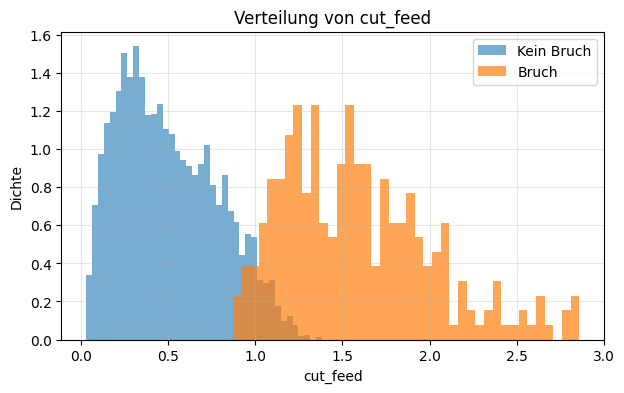

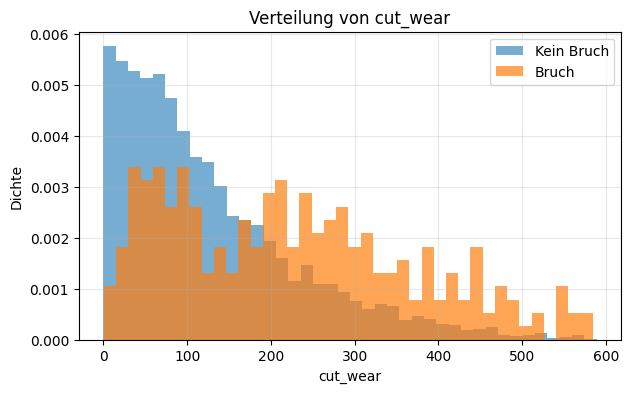

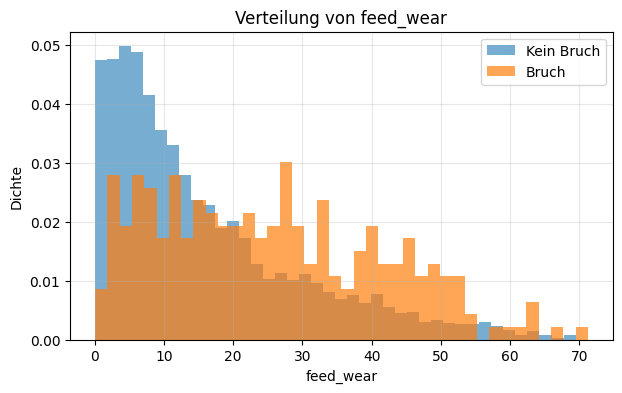

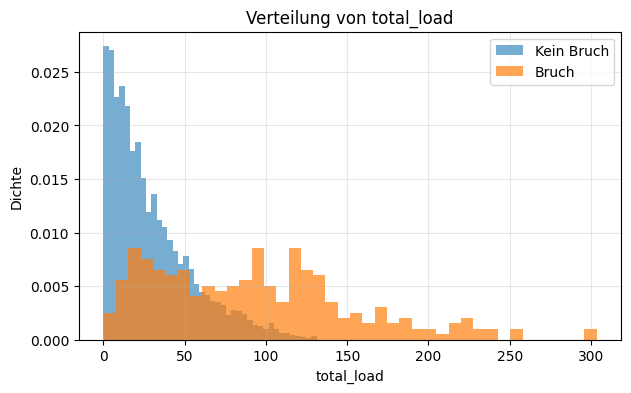

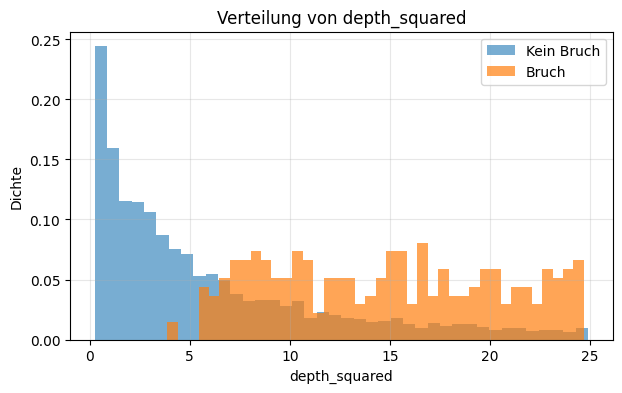

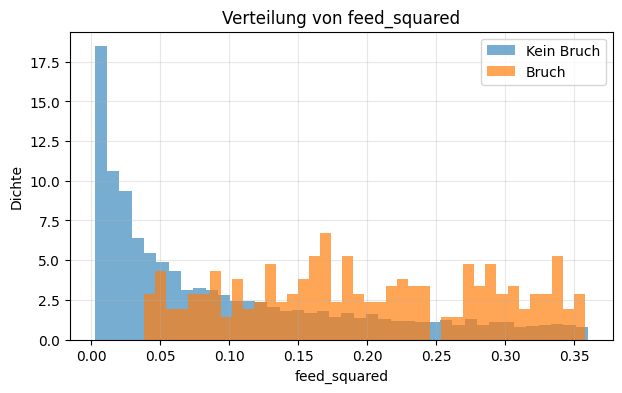

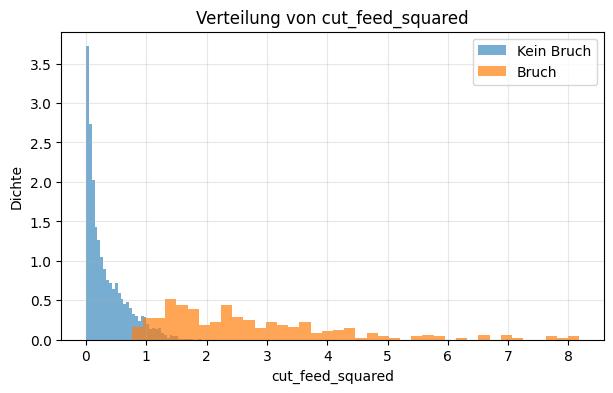

In [95]:
# ── Verteilungen der neuen Features untersuchen ───────────────────────────────

# Für jedes neue Feature einen Plot erstellen
for feature in neue_features:

    # Neue Abbildung erstellen
    plt.figure(figsize=(7,4))

    # Werte ohne Werkzeugbruch auswählen
    werte_kein_bruch = df_features[df_features["tool_breakage"] == 0][feature]

    # Werte mit Werkzeugbruch auswählen
    werte_bruch = df_features[df_features["tool_breakage"] == 1][feature]

    # Histogramm für Klasse 0 zeichnen
    plt.hist(werte_kein_bruch, bins=40, alpha=0.6, density=True, label="Kein Bruch")

    # Histogramm für Klasse 1 zeichnen
    plt.hist(werte_bruch, bins=40, alpha=0.7, density=True, label="Bruch")

    # x-Achse beschriften
    plt.xlabel(feature)

    # y-Achse beschriften
    plt.ylabel("Dichte")

    # Titel setzen
    plt.title("Verteilung von " + feature)

    # Legende anzeigen
    plt.legend()

    # Diagramm anzeigen
    plt.show()


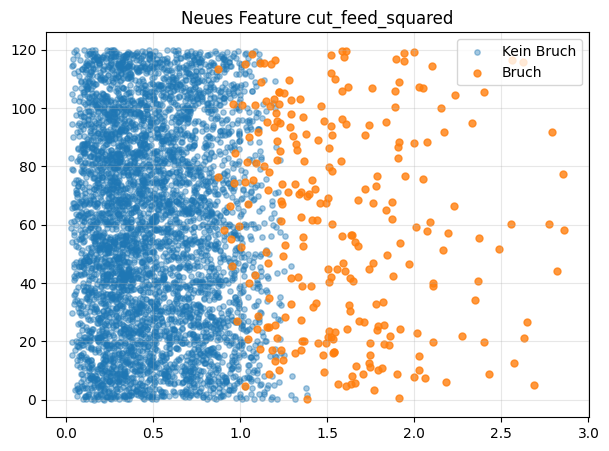

In [ ]:
# ── Plot: cut_feed gegen Werkzeugverschleiß ───────────────────────

# Neue Abbildung erstellen
plt.figure(figsize=(7,5))

# Punkte ohne Bruch für cut_feed
plt.scatter(df_features[df_features["tool_breakage"] == 0]["cut_feed"],df_features[df_features["tool_breakage"] == 0]["tool_wear_min"],s=15,alpha=0.4,label="Kein Bruch")

# Punkte mit Bruch für cut_feed
plt.scatter(df_features[df_features["tool_breakage"] == 1]["cut_feed"],df_features[df_features["tool_breakage"] == 1]["tool_wear_min"],s=25,alpha=0.8,label="Bruch")

# x-Achse beschriften
plt.xlabel("cut_feed = Schnitttiefe * Vorschub")

# y-Achse beschriften
plt.ylabel("Werkzeugverschleiß [min]")

# Titel setzen
plt.title("Neues Feature cut_feed vs Werkzeugverschleiß")

# Legende anzeigen
plt.legend()

# Diagramm anzeigen
plt.show()


In [97]:
# ── Kurze Bewertung der Feature-Engineering-Ergebnisse ───────────────────────

print("Interpretation:")

print("Die EDA zeigt, dass Werkzeugbrüche besonders bei hoher Schnitttiefe und hohem Vorschub auftreten.")

print("Deshalb ist das neue Feature cut_feed sinnvoll, weil es beide Belastungsgrößen kombiniert.")

print("Quadratische Features helfen, weil die Grenze zwischen Bruch und Nicht-Bruch dadurch linear trennbar wird.")



Interpretation:
Die EDA zeigt, dass Werkzeugbrüche besonders bei hoher Schnitttiefe und hohem Vorschub auftreten.
Deshalb ist das neue Feature cut_feed sinnvoll, weil es beide Belastungsgrößen kombiniert.
Quadratische Features helfen, weil die Grenze zwischen Bruch und Nicht-Bruch dadurch linear trennbar wird.
